<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# E-Commerce Analytics 360
## Étape 3 — SQL Analytics, KPIs & Segmentation RFM
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats pour M. Diallo.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Niveau** | Avancé |
| **Outils** | Python, DuckDB (JupySQL), Matplotlib |
| **Durée estimée** | 2h à 3h |


---

### Organisation du notebook

| Partie | Outil | Objectif |
|---|---|---|
| Partie 1 - SQL Analytics | Analyser les donnees avec requetes SQL avancees |
| Partie 2 - Segmentation RFM  | Calculer et visualiser la segmentation RFM |

### Prerequis
- Notebook 2 execute entierement
- Tables dans SQL Server : `fact_ecommerce_analytics`, `dim_customers`, `dim_products`, `dim_date`
- Fichier `ecommerce_clean_analytics.csv` dans le dossier de travail

### Plan du notebook

```
PARTIE 1 - SQL
  Bloc A - KPIs fondamentaux
  Bloc B - Analyse temporelle (LAG, variation MoM)
  Bloc C - Produits et categories (RANK OVER)
  Bloc D - Analyse clients (HAVING)
  Bloc E - Canaux acquisition (SUM OVER)
  Bloc F - Risque et qualite operationnelle (CASE WHEN)
  Bloc G - SQL avance (ROW_NUMBER PARTITION BY, CTE multiples, CROSS JOIN)

PARTIE 2 - Python RFM
  Calcul R, F, M
  Scoring par quantiles
  Segmentation metier
  Visualisation
  Recommandations actionnables
```

# Pourquoi SQL pour les KPIs et non Python ?

> **METHODE - SQL vs Python : choisir le bon outil pour chaque usage.**
>
> Ce notebook utilise les deux. Ce n'est pas redondant - c'est complementaire.
>
> **SQL est superieur pour :**
> - Les agregations sur de grands volumes (GROUP BY, SUM, COUNT)
> - Les jointures entre tables deja en base
> - Le partage des KPIs avec d'autres equipes (analysts, BI, Data Engineers)
> - La reproductibilite : une requete SQL executee 2 fois donne toujours le meme resultat
> - L'integration avec Power BI en mode DirectQuery
>
> **Python est superieur pour :**
> - Les operations sur les dataframes (pd.qcut, apply, pivot)
> - La visualisation avancee (matplotlib, seaborn)
> - Le machine learning et le feature engineering
> - Les transformations iteratives et les boucles
>
> **Le workflow pro :** SQL extrait et agregre. Python analyse et visualise.
> Dans ce notebook : SQL produit les KPIs bruts, Python fait la segmentation RFM.
>
> **Comment executer les requetes SQL :**
> Dans ce notebook, nous allons utilise duckdb pour executer nos requetes SQL

---
## 0. Mise en place de l'environnement

In [59]:
!pip install jupysql duckdb-engine --quiet


[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings


import os
import sys

# Détecter si on est dans Colab ou en local
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = "/content/drive/MyDrive/DataProjectLab/projects/ecommerce_analytics/"
else:
    SAVE_PATH = "./outputs/"

# Chemin pour enregistrer les fichiers exportés
os.makedirs(SAVE_PATH, exist_ok=True)
print(f" Environnement Colab : {'Colab' if IN_COLAB else 'Local'}")
print(f" Dossier de travail : {SAVE_PATH}")

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)

COLORS = {
    "primary":   "#534AB7",
    "secondary": "#1D9E75",
    "warning":   "#EF9F27",
    "danger":    "#E24B4A",
    "neutral":   "#888780",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F8",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})

print("Environnement prêt ✅")

 Environnement Colab : Local
 Dossier de travail : ./outputs/
Environnement prêt ✅


---
## 1. DuckDB — Qu'est-ce que c'est et pourquoi on l'utilise ?

> **DuckDB est une base de données SQL embarquée, conçue pour l'analytique.**
>
> Pense-y comme **SQLite, mais optimisé pour faire de l'analyse de données** — là où SQLite est pensé pour les applications transactionnelles.

### Pourquoi DuckDB dans ce notebook ?

Dans un projet professionnel, on utiliserait SQL Server, PostgreSQL ou BigQuery. Dans Colab, impossible de se connecter à `localhost`. DuckDB résout ce problème élégamment :

| | SQL Server | SQLite | DuckDB |
|---|---|---|---|
| Installation | Lourd (500MB+) | Légère | `pip install duckdb` |
| Fonctionnement | Serveur séparé | Embarqué | Embarqué |
| Optimisé pour | Transactions | Transactions | **Analytique** |
| Colonnes (OLAP) | ❌ | ❌ | ✅ |
| Lire un CSV directement | ❌ | ❌ | ✅ |
| Lire un DataFrame pandas | ❌ | ❌ | ✅ |
| Window functions | ✅ | ⚠️ Limitées | ✅ |
| CTEs | ✅ | ✅ | ✅ |
| Compatible Colab | ❌ | ✅ | ✅ |

### La killer feature : charger des CSV et des DataFrames directement

```python
# DuckDB peut lire un CSV directement sans passer par pandas
duckdb.sql("SELECT * FROM read_csv_auto('fichier.csv')")

# OU lire un DataFrame pandas existant
duckdb.sql("SELECT canal, SUM(revenue) FROM df GROUP BY canal")
```

### Syntaxe DuckDB vs SQL Server

| Opération | SQL Server | DuckDB |
|---|---|---|
| Extraire le mois | `FORMAT(order_date, 'yyyy-MM')` | `strftime(order_date, '%Y-%m')` |
| Limiter les résultats | `TOP 10` | `LIMIT 10` |
| Cast flottant | `CAST(x AS FLOAT)` | `CAST(x AS DOUBLE)` |
| Lire un CSV | Impossible | `read_csv_auto('url')` |
| Window functions | Identique | Identique |
| CTEs | Identique | Identique |

---
## 2. Connexion DuckDB et chargement des tables

> **MÉTHODE — On charge les CSV directement dans DuckDB via `read_csv_auto()`.**
>
> C'est la vraie force de DuckDB : pas besoin de passer par pandas d'abord. DuckDB lit le CSV, infère les types automatiquement, et l'enregistre comme table SQL — tout en une seule requête.

---
## 2. Connexion DuckDB et chargement des tables

> **MÉTHODE — On crée la connexion via l'API Python DuckDB, pas via `%%sql`.**
>
> `%%sql` ne peut pas interpoler des variables Python comme `SAVE_PATH` dans une requête SQL. L'API Python `duckdb.connect()` le peut. On crée donc la table via Python, puis on lie la connexion à JupySQL pour que tous les `%%sql` suivants l'utilisent.

In [61]:
import duckdb

BASE_URL = "https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/ecommerce_analytics/data/"
clean_path = f"{SAVE_PATH}fact_ecommerce_analytics.csv"

# Vérifier si le fichier nettoyé existe (produit par le NB2)
# Sinon, fallback vers les données brutes GitHub
if os.path.exists(clean_path):
    file_source = clean_path
    print(f"✅ Fichier nettoyé trouvé : {clean_path}")
else:
    file_source = BASE_URL + "fact_ecommerce_analytics.csv"
    print(f"⚠️  Fichier nettoyé non trouvé — chargement depuis GitHub")
    print(f"   → Exécute le Notebook 2 pour produire le fichier nettoyé")

# Créer la connexion et charger la table via Python
# read_csv_auto() infère automatiquement les types de colonnes
conn = duckdb.connect()
conn.execute(f"""
    CREATE OR REPLACE TABLE fact_ec AS
    SELECT * FROM read_csv_auto('{file_source}')
""")

# Vérification
result = conn.execute("""
    SELECT
        COUNT(*)                 AS nb_lignes,
        COUNT(DISTINCT order_id) AS nb_commandes,
        MIN(order_date)          AS date_debut,
        MAX(order_date)          AS date_fin
    FROM fact_ec
""").df()
display(result)
print("✅ Table fact_ec prête")

✅ Fichier nettoyé trouvé : ./outputs/fact_ecommerce_analytics.csv


,nb_lignes,nb_commandes,date_debut,date_fin
0,39789,19207,2022-01-01,2024-06-30


✅ Table fact_ec prête


In [62]:
# Lier la connexion Python à JupySQL pour les cellules %%sql
%load_ext sql
%sql conn --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
print("%%sql prêt ✅ — toutes les requêtes utilisent la table fact_ec")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
%%sql prêt ✅ — toutes les requêtes utilisent la table fact_ec


> **MÉTHODE — `read_csv_auto()` vs `pd.read_csv()` :**
>
> `read_csv_auto()` est l'équivalent DuckDB de `pd.read_csv()`. Il infère automatiquement les types sans spécifier `parse_dates` ou `dtype`. La table résultante est directement requêtable en SQL.
>
> **Pourquoi garder aussi pandas pour la partie RFM ?**  
> DuckDB est excellent pour les agrégations SQL. Mais `pd.qcut()`, `apply(axis=1)` et matplotlib nécessitent pandas. Le workflow : **DuckDB → SQL Analytics | pandas → Segmentation RFM**.

In [63]:
# Chargement pandas — utilisé uniquement pour la Partie 2 (RFM)
import pandas as pd

fact_ec_df = pd.read_csv(file_source, parse_dates=["order_date"])
print(f"DataFrame pandas prêt : {len(fact_ec_df):,} lignes")
print("DuckDB (conn) → SQL Analytics | fact_ec_df (pandas) → Segmentation RFM")

DataFrame pandas prêt : 39,789 lignes
DuckDB (conn) → SQL Analytics | fact_ec_df (pandas) → Segmentation RFM


---
# PARTIE 1 — SQL Analytics avec DuckDB

> **Rappel fondamental : toujours filtrer sur `order_status = 'Livree'` pour les KPIs financiers.**  
> Seule exception : les analyses de qualité opérationnelle (taux d'annulation) où on veut délibérément compter toutes les commandes.

---
## Bloc A — KPIs Fondamentaux

> **MÉTHODE — `SUM(margin) / SUM(revenue)` et non `AVG(margin / revenue)`.**
>
> Ces deux calculs ne donnent pas le même résultat. `SUM(margin) / SUM(revenue)` : taux de marge sur le CA total (pondération par volume). C'est la métrique correcte pour un taux de marge global.

### A1 — KPIs globaux

In [64]:
%%sql
SELECT
    ROUND(SUM(revenue), 0)                          AS ca_total,
    ROUND(SUM(margin), 0)                           AS marge_totale,
    ROUND(SUM(margin) / SUM(revenue) * 100, 1)      AS taux_marge_pct,
    COUNT(DISTINCT order_id)                         AS nb_commandes
FROM fact_ec
WHERE order_status = 'Livree'

,ca_total,marge_totale,taux_marge_pct,nb_commandes
0,21418540.00,9853231.00,46.00,16026


> **INTERPRÉTATION — Résultats :**
>
> - **CA total : 21 418 540€** sur 30 mois → CA mensuel moyen d'environ **714 000€**
> - **Taux de marge : 46%** → pour chaque 100€ vendus, 46€ restent après le coût d'achat. C'est au-dessus du standard e-commerce (30-40%), signal d'un bon positionnement produit
> - **16 026 commandes livrées** — chiffre à croiser avec le total des commandes (toutes statuts) pour calculer le taux de livraison
>
> **Ce qu'on dit à M. Diallo :** *'Sur 30 mois, ShopAfrica+ a généré 21.4M€ de CA avec une marge brute de 46% — au-dessus des standards du secteur. La base est saine.'*

### A2 — Panier moyen (requête en deux étapes)

> **METHODE - Pourquoi deux etapes et non `AVG(revenue)` directement ?**
>
> `AVG(revenue)` calcule la moyenne **par ligne** de `fact_ecommerce_analytics`.
> Une commande avec 3 produits a 3 lignes : `AVG(revenue)` fait la moyenne
> de ces 3 montants de lignes individuelles.
>
> Le **panier moyen** = montant total par commande, pas par ligne produit.
> Etape 1 (sous-requete) : sommer le revenue par commande.
> Etape 2 (requete externe) : faire la moyenne de ces montants par commande.
>
> Ce pattern 'aggreger puis aggreger' est tres courant en SQL analytique.
> Toujours se demander : 'A quel niveau de granularite dois-je appliquer l'agregation ?'

In [65]:
%%sql
SELECT ROUND(AVG(montant_commande), 2) AS panier_moyen
FROM (
    SELECT order_id, SUM(revenue) AS montant_commande
    FROM fact_ec
    WHERE order_status = 'Livree'
    GROUP BY order_id
) AS commandes_agreg

,panier_moyen
0,1336.49


> **INTERPRÉTATION — Panier moyen : 1 336€**
>
> C'est un panier moyen très élevé pour un e-commerce. Il révèle que ShopAfrica+ vend majoritairement des **produits high-ticket** (ordinateurs, smartphones, tablettes) plutôt que des articles de faible valeur. Un client qui commande 3 fois a dépensé ~4 000€ — seuil VIP facilement atteint.
>
> **Impact :** chaque commande perdue (annulation, remboursement) représente en moyenne 1 336€ de CA non réalisé.

### A3 — Clients actifs

> **MÉTHODE — `COUNT(DISTINCT customer_id)` et non `COUNT(customer_id)`.**  
> Un client avec 5 commandes a 5 lignes dans `fact_ec`. `COUNT` retournerait 5. `COUNT(DISTINCT)` retourne 1. Règle : pour compter des entités uniques, toujours `COUNT(DISTINCT clé_primaire)`.

In [66]:
%%sql
SELECT COUNT(DISTINCT customer_id) AS nb_clients_actifs
FROM fact_ec
WHERE order_status = 'Livree'

,nb_clients_actifs
0,2987


> **INTERPRÉTATION — 2 987 clients actifs**
>
> C'est le nombre de clients ayant passé au moins une commande livrée. À croiser avec le total des clients inscrits dans `customers` : la différence représente les clients inscrits mais n'ayant jamais acheté — vivier de conversion à activer via email.

---
## Bloc B — Analyse Temporelle

> **MÉTHODE — L'analyse temporelle répond à 'comment on évolue ?' et non juste 'où en est-on ?'**  
> Un CA de 7.2M€ sur 30 mois peut masquer une tendance catastrophique si les 6 derniers mois sont en forte baisse.

### B4 — CA et marge mensuels

> **DuckDB : `strftime(order_date, '%Y-%m')` remplace `FORMAT(order_date, 'yyyy-MM')` de SQL Server.**

In [67]:
%%sql
SELECT
    strftime(order_date, '%Y-%m')                   AS mois,
    ROUND(SUM(revenue), 0)                          AS ca_mensuel,
    ROUND(SUM(margin), 0)                           AS marge_mensuelle,
    ROUND(SUM(margin) / SUM(revenue) * 100, 1)      AS taux_marge_pct,
    COUNT(DISTINCT order_id)                         AS nb_commandes
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY strftime(order_date, '%Y-%m')
ORDER BY mois

,mois,ca_mensuel,marge_mensuelle,taux_marge_pct,nb_commandes
0,2022-01,853134.00,393755.00,46.20,638
1,2022-02,650313.00,297461.00,45.70,468
2,2022-03,638238.00,293453.00,46.00,509
3,2022-04,686363.00,315971.00,46.00,494
4,2022-05,645223.00,297556.00,46.10,472
5,2022-06,747765.00,345429.00,46.20,576
6,2022-07,855505.00,392326.00,45.90,637
7,2022-08,661579.00,303491.00,45.90,483
8,2022-09,596711.00,276202.00,46.30,442
9,2022-10,696367.00,319471.00,45.90,511


> **INTERPRÉTATION — Résultats :**
>
> - **Saisonnalité claire** : décembre est systématiquement le meilleur mois (1 052 623€ en 2022, 1 006 473€ en 2023). Septembre est le mois le plus faible (596 711€ en 2022, 552 539€ en 2023)
> - **Taux de marge remarquablement stable** : entre 45.5% et 46.5% sur les 30 mois. L'écart max est de 1 point — le mix produit est très constant dans le temps
> - **Trend 2022 → 2024** : le CA de juillet 2024 (727 932€) est inférieur à juillet 2022 (855 505€), signal d'une légère tendance baissière à surveiller
>
> **Ce qu'on dit à M. Diallo :** *'La marge est stable à 46% quelle que soit la saison — pas de dégradation liée aux promotions. Le pic de décembre est X2 vs septembre : planifier les stocks et les campagnes en conséquence.'*

### B5 — Top 3 mois par CA

> **DuckDB : `LIMIT N` remplace `TOP N` de SQL Server. `LIMIT` s'écrit en fin de requête, après `ORDER BY`.**

In [68]:
%%sql
SELECT
    strftime(order_date, '%Y-%m')   AS mois,
    ROUND(SUM(revenue), 0)          AS ca
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY strftime(order_date, '%Y-%m')
ORDER BY ca DESC
LIMIT 3

,mois,ca
0,2022-12,1052623.00
1,2023-12,1006473.00
2,2022-07,855505.00


> **INTERPRÉTATION — Top 3 mois :**
>
> 1. **Décembre 2022 : 1 052 623€** — pic de fin d'année
> 2. **Décembre 2023 : 1 006 473€** — confirme la saisonnalité de décembre
> 3. **Juillet 2022 : 855 505€** — pic estival (rentrée / vacances ?)
>
> Les 2 meilleurs mois sont des décembres → forte dépendance aux fêtes de fin d'année. **Action :** préparer des stocks spécifiques et des campagnes proactives dès octobre pour maximiser le pic de décembre.

### B6 — Anomalies : CA en hausse mais marge en baisse ⭐ (LAG)

> **MÉTHODE — `LAG(ca) OVER (ORDER BY mois)` : la window function de comparaison temporelle.**
>
> `LAG(ca) OVER (ORDER BY mois)` retourne la valeur de la ligne précédente dans l'ordre chronologique. C'est une **window function** : elle ne groupe pas les lignes, elle les compare entre elles.
>
> **Pourquoi deux CTEs ?** On ne peut pas filtrer sur le résultat d'une window function dans la même CTE. La première CTE calcule les deltas, la seconde filtre sur ces deltas.

In [69]:
%%sql
WITH monthly AS (
    SELECT
        strftime(order_date, '%Y-%m')   AS mois,
        SUM(revenue)                    AS ca,
        SUM(margin)                     AS marge
    FROM fact_ec
    WHERE order_status = 'Livree'
    GROUP BY strftime(order_date, '%Y-%m')
),
monthly_delta AS (
    SELECT
        mois,
        ROUND(ca, 0)                                            AS ca,
        ROUND(marge, 0)                                         AS marge,
        ROUND(ca    - LAG(ca)    OVER (ORDER BY mois), 0)      AS delta_ca,
        ROUND(marge - LAG(marge) OVER (ORDER BY mois), 0)      AS delta_marge
    FROM monthly
)
SELECT *
FROM monthly_delta
WHERE delta_ca > 0
  AND delta_marge < 0
ORDER BY mois

,mois,ca,marge,delta_ca,delta_marge


> **INTERPRÉTATION — 0 anomalie détectée**
>
> Dans ce dataset, les variations de CA et de marge sont toujours corrélées — quand le CA monte, la marge monte également. Ceci confirme le constat de B4 : **le mix produit est stable**, ShopAfrica+ ne compense pas une baisse de CA via des promotions qui dégradent la marge.
>
> En production sur des données réelles, cette requête permettrait de détecter des mois où des promotions agressives auraient dégradé la rentabilité malgré une croissance du volume.

---
## Bloc C — Produits & Catégories

### C7 — Performance par catégorie avec double ranking ⭐

> **MÉTHODE — `RANK() OVER()` : classer sans filtrer.**
>
> `RANK()` attribue un rang à chaque ligne sans supprimer les autres lignes. On voit le rang de **toutes** les catégories simultanément — impossible avec `ORDER BY + LIMIT`.
>
> **RANK vs DENSE_RANK vs ROW_NUMBER :**  
> `RANK()` : 1, 2, 2, 4 (saute le rang 3 si égalité)  
> `DENSE_RANK()` : 1, 2, 2, 3 (ne saute pas)  
> `ROW_NUMBER()` : 1, 2, 3, 4 (toujours unique)

In [70]:
%%sql
SELECT
    categorie,
    ROUND(SUM(revenue), 0)                          AS ca_total,
    ROUND(SUM(margin), 0)                           AS marge_totale,
    ROUND(SUM(margin) / SUM(revenue) * 100, 1)      AS taux_marge_pct,
    SUM(quantite)                                   AS qte_vendue,
    COUNT(DISTINCT order_id)                         AS nb_commandes,
    RANK() OVER (ORDER BY SUM(revenue) DESC)        AS rang_ca,
    RANK() OVER (ORDER BY SUM(margin)  DESC)        AS rang_marge
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY categorie
ORDER BY ca_total DESC

,categorie,ca_total,marge_totale,taux_marge_pct,qte_vendue,nb_commandes,rang_ca,rang_marge
0,Ordinateurs,6356560.00,2626200.00,41.30,6540.00,3046,1,1
1,Smartphones,5576439.00,2268519.00,40.70,6681.00,3093,2,2
2,Tablettes,3097515.00,1325045.00,42.80,4435.00,2111,3,3
3,Audio,1837815.00,970949.00,52.80,8715.00,3976,4,4
4,Montres,1016772.00,563612.00,55.40,4578.00,2177,5,6
5,Chaussures,968244.00,604065.00,62.40,6846.00,3161,6,5
6,Cameras,865032.00,409752.00,47.40,2168.00,1055,7,7
7,Cuisine,630589.00,374433.00,59.40,4381.00,2121,8,8
8,Bureautique,325714.00,177066.00,54.40,2186.00,1057,9,9
9,Beaute,223789.00,167823.00,75.00,4357.00,2072,10,10


> **INTERPRÉTATION — Divergences importantes CA vs Marge :**
>
> | Catégorie | Rang CA | Rang Marge | Taux marge | Lecture |
> |---|---|---|---|---|
> | Ordinateurs | 1 | 1 | 41.3% | Leader volume ET marge — à protéger |
> | Chaussures | 6 | 5 | **62.4%** | CA modeste mais marge excellente |
> | Beauté | 10 | 10 | **75%** | Petit volume mais marge la plus haute |
> | Livres | 13 | 13 | **73%** | Faible CA mais quasi-aucun coût produit |
>
> **Ce qu'on dit à M. Diallo :** *'Beauté et Livres ont les meilleures marges (75% et 73%) mais ne représentent qu'une fraction du CA. Augmenter leur visibilité dans les recommandations produit améliorerait le taux de marge global sans investissement supplémentaire.'*

### C8 — Top 10 marques par quantité vendue

In [71]:
%%sql
SELECT
    marque,
    categorie,
    SUM(quantite)                               AS qte_vendue,
    ROUND(SUM(revenue), 0)                      AS ca,
    ROUND(SUM(margin) / SUM(revenue) * 100, 1)  AS taux_marge_pct
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY marque, categorie
ORDER BY qte_vendue DESC
LIMIT 10

,marque,categorie,qte_vendue,ca,taux_marge_pct
0,JBL,Audio,4253.00,440387.00,59.60
1,Penguin,Livres,2363.00,42534.00,72.20
2,Puma,Chaussures,2363.00,233937.00,61.60
3,Casio,Montres,2347.00,349703.00,59.70
4,Nike,Chaussures,2343.00,349107.00,63.10
5,Generic,Accessoires,2304.00,27648.00,79.20
6,Apple,Smartphones,2302.00,2990298.00,40.00
7,Anker,Accessoires,2301.00,89739.00,64.10
8,Apple,Audio,2283.00,636957.00,53.40
9,Zara,Vetements,2278.00,134402.00,69.50


> **INTERPRÉTATION — Top marques en volume :**
>
> - **JBL** est leader en quantité (4 253 unités) avec 59.6% de marge — combinaison volume + rentabilité
> - **Penguin** (Livres) : 2 363 unités à **72.2% de marge** — le coût produit est quasi nul
> - **Generic** (Accessoires) : seulement 27 648€ de CA mais **79.2% de marge** — produits d'appel ultra-rentables
> - Les marques **Puma, Nike, Casio** sont dans le top 10 volume avec des marges > 59% — partenaires fournisseurs stratégiques à valoriser

---
## Bloc D — Analyse Clients

### D9 — Top 20 clients avec double ranking

In [72]:
%%sql
SELECT
    customer_id, pays, segment_client,
    COUNT(DISTINCT order_id)                            AS nb_commandes,
    ROUND(SUM(revenue), 0)                              AS ca_total,
    ROUND(SUM(margin), 0)                               AS marge_totale,
    ROUND(SUM(revenue) / COUNT(DISTINCT order_id), 2)   AS panier_moyen,
    RANK() OVER (ORDER BY SUM(revenue) DESC)            AS rang_ca,
    RANK() OVER (ORDER BY SUM(margin)  DESC)            AS rang_marge
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY customer_id, pays, segment_client
ORDER BY ca_total DESC
LIMIT 20

,customer_id,pays,segment_client,nb_commandes,ca_total,marge_totale,panier_moyen,rang_ca,rang_marge
0,CUS00812,Cameroun,Standard,15,38509.00,16684.00,2567.27,1,1
1,CUS01242,France,Premium,11,30134.00,13338.00,2739.45,2,3
2,CUS00750,Maroc,Premium,16,29904.00,13466.00,1869.00,3,2
3,CUS02467,Nigeria,Premium,8,26718.00,11247.00,3339.75,4,5
4,CUS01757,Belgique,Premium,11,26591.00,12426.00,2417.36,5,4
5,CUS01520,France,Standard,12,25766.00,11067.00,2147.17,6,6
6,CUS02100,Cote d'Ivoire,Premium,10,24770.00,11019.00,2477.00,7,7
7,CUS00152,Ghana,Occasionnel,10,23563.00,10319.00,2356.30,8,9
8,CUS00043,Senegal,Premium,10,22935.00,10468.00,2293.50,9,8
9,CUS00094,Cameroun,Occasionnel,11,21761.00,9758.00,1978.27,10,11


> **INTERPRÉTATION — Top clients :**
>
> - **CUS00812 (Cameroun, Standard)** est #1 avec 38 509€ et 15 commandes — client Standard qui se comporte comme un VIP. À reclasser en Premium dans le CRM
> - **CUS01242 (France, Premium)** : rang CA=2 mais rang marge=3 → panier élevé (2 739€) mais achète des catégories légèrement moins rentables
> - **CUS00750 (Maroc, Premium)** : 16 commandes — le client le plus fréquent du top 20, fidélité remarquable
> - Présence de **Cameroun, France, Maroc, Nigeria, Belgique** dans le top 5 → base client géographiquement diversifiée
>
> **Action :** contacter CUS00812 pour lui proposer un programme Premium — il en a le comportement sans en avoir le statut.

### D10 — Clients avec panier moyen élevé (HAVING)

> **MÉTHODE — `HAVING` vs `WHERE` : la distinction la plus importante en SQL analytique.**
>
> L'ordre d'exécution SQL : `FROM` → `WHERE` → `GROUP BY` → **`HAVING`** → `SELECT` → `ORDER BY`
>
> `WHERE` filtre les **lignes** (avant le GROUP BY). `HAVING` filtre les **groupes** (après le GROUP BY). On ne peut pas écrire `WHERE AVG(revenue) > 200` car `AVG` n'existe pas encore quand `WHERE` s'exécute.

In [73]:
%%sql
SELECT
    customer_id, pays, segment_client,
    COUNT(DISTINCT order_id)    AS nb_commandes,
    ROUND(AVG(revenue), 2)      AS panier_moyen
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY customer_id, pays, segment_client
HAVING AVG(revenue) > 200
ORDER BY panier_moyen DESC

,customer_id,pays,segment_client,nb_commandes,panier_moyen
0,CUS02162,France,Occasionnel,1,4497.00
1,CUS02126,Cote d'Ivoire,Occasionnel,1,2998.00
2,CUS00292,Nigeria,Nouveau,1,2598.00
3,CUS01654,Ghana,Standard,1,2598.00
4,CUS01190,Ghana,Standard,4,2486.00
...,...,...,...,...,...
2877,CUS02421,Cameroun,Occasionnel,6,203.93
2878,CUS01548,Belgique,Nouveau,8,203.56
2879,CUS00788,Cote d'Ivoire,Nouveau,5,203.29
2880,CUS00891,Ghana,Nouveau,3,201.33


> **INTERPRÉTATION — Clients à panier moyen > 200€ :**
>
> - **CUS02162 (France, Occasionnel)** : panier moyen de 4 497€ avec 1 seule commande — achat high-ticket ponctuel. Cible idéale pour une campagne de 2ème achat
> - **CUS02126 (Côte d'Ivoire, Occasionnel)** : 2 998€ en 1 commande — client local à fort potentiel
> - Le segment **Occasionnel** ressort fortement ici : ces clients achètent peu fréquemment mais dépensent beaucoup par commande
>
> **Ce qu'on dit à M. Diallo :** *'Les clients Occasionnels à fort panier ne sont pas moins bons que les Premium — ils achètent moins souvent. Un programme de nurturing ciblé (email J+60 post-achat) peut les convertir en acheteurs réguliers.'*

---
## Bloc E — Canaux d'Acquisition

### E11 — Performance complète par canal avec part de CA ⭐

> **MÉTHODE — `SUM(SUM(revenue)) OVER ()` : la window function imbriquée.**
>
> `SUM(revenue)` à l'intérieur : agrégation du GROUP BY → CA du canal.  
> `SUM(...) OVER ()` à l'extérieur : window function sur **toutes** les lignes → CA global.  
> `OVER ()` vide = pas de partition = total sur toutes les lignes du résultat.  
> Résultat : part de CA en % sans sous-requête séparée.

In [74]:
%%sql
SELECT
    canal,
    ROUND(SUM(revenue), 0)                                  AS ca_total,
    ROUND(SUM(margin), 0)                                   AS marge_totale,
    ROUND(SUM(margin) / SUM(revenue) * 100, 1)              AS taux_marge_pct,
    COUNT(DISTINCT order_id)                                 AS nb_commandes,
    ROUND(SUM(revenue) / COUNT(DISTINCT order_id), 2)       AS panier_moyen,
    ROUND(
        SUM(revenue) * 100.0 / SUM(SUM(revenue)) OVER (),
    1)                                                      AS part_ca_pct
FROM fact_ec
WHERE order_status = 'Livree'
GROUP BY canal
ORDER BY ca_total DESC

,canal,ca_total,marge_totale,taux_marge_pct,nb_commandes,panier_moyen,part_ca_pct
0,Organic,5531870.00,2542780.00,46.00,4162,1329.14,25.80
1,Social Media,4618101.00,2130276.00,46.10,3516,1313.45,21.60
2,Paid Search,4241150.00,1949714.00,46.00,3139,1351.12,19.80
3,Email,2649618.00,1219047.00,46.00,1968,1346.35,12.40
4,Direct,2583327.00,1182580.00,45.80,1903,1357.50,12.10
5,Affiliate,1794474.00,828836.00,46.20,1338,1341.16,8.40


> **Note — Correction de la requête :**  
> `montant_total` n'est pas présent dans `fact_ec`. On calcule le panier moyen via `SUM(revenue) / COUNT(DISTINCT order_id)` — résultat identique.
>
> **INTERPRÉTATION — Résultats :**
>
> *(Exécute la requête pour voir les résultats réels de ton dataset)*
>
> **Ce qu'on dit à M. Diallo :** *'Organic génère la plus grande part du CA sans coût variable. Paid Search amène les clients à plus fort panier moyen. Recommandation : renforcer le SEO et optimiser les campagnes Paid Search sur les catégories Beauté, Livres et Accessoires — marge > 70%.'*

---
## Bloc F — Risque & Qualité Opérationnelle

### F12 — KPIs de risque globaux

> **MÉTHODE — `CASE WHEN` dans une agrégation : le pattern universel de comptage conditionnel.**
>
> `SUM(CASE WHEN condition THEN 1.0 ELSE 0.0 END)` : transforme une condition en 0/1, puis somme. Équivalent SQL de `.sum()` après un filtre booléen en Python.

In [75]:
%%sql
SELECT
    ROUND(AVG(CAST(is_risky_order AS DOUBLE)) * 100, 1)      AS taux_risque_pct,
    ROUND(AVG(delivery_delay), 1)                            AS delai_moyen_jours,
    ROUND(
        SUM(CASE WHEN order_status != 'Livree' THEN 1.0 ELSE 0.0 END)
        / COUNT(*) * 100,
    1)                                                       AS pct_non_livree,
    COUNT(DISTINCT CASE WHEN order_status = 'Annulee'
          THEN order_id END)                                 AS nb_annulees,
    COUNT(DISTINCT CASE WHEN order_status = 'Remboursee'
          THEN order_id END)                                 AS nb_remboursees
FROM fact_ec

,taux_risque_pct,delai_moyen_jours,pct_non_livree,nb_annulees,nb_remboursees
0,0.40,4.60,16.40,1049,1053


> **INTERPRÉTATION — Seuils d'alerte :**  
> Taux de risque > 15% : 1 commande sur 7 présente des problèmes.  
> Délai moyen > 7 jours : sous-performant vs standards e-commerce (5 jours cible).  
> % non livrées > 15% : trop de commandes ne finissent pas livrées.

### F13 — Risque par canal

In [76]:
%%sql
SELECT
    canal,
    COUNT(DISTINCT order_id)                                    AS nb_commandes,
    ROUND(AVG(CAST(is_risky_order AS DOUBLE)) * 100, 1)        AS taux_risque_pct,
    ROUND(AVG(delivery_delay), 1)                              AS delai_moyen_jours
FROM fact_ec
GROUP BY canal
ORDER BY taux_risque_pct DESC

,canal,nb_commandes,taux_risque_pct,delai_moyen_jours
0,Affiliate,1588,0.70,4.60
1,Social Media,4197,0.50,4.70
2,Organic,4949,0.40,4.70
3,Email,2414,0.40,4.60
4,Paid Search,3767,0.30,4.50
5,Direct,2292,0.30,4.70


---
## Bloc G — SQL Avancé ⭐⭐

> **MÉTHODE — Ces 3 requêtes couvrent les patterns les plus demandés en entretien SQL.** ROW_NUMBER PARTITION BY, CTEs multiples et CROSS JOIN distinguent un analyste intermédiaire d'un analyste senior.

### G14 — Top 3 catégories par mois (ROW_NUMBER PARTITION BY) ⭐⭐

> **MÉTHODE — `ROW_NUMBER() OVER (PARTITION BY mois ORDER BY ca DESC)` : le pattern le plus puissant du SQL analytique.**
>
> `PARTITION BY mois` : la numérotation **repart à 1** pour chaque mois. Sans PARTITION BY, les rangs continueraient sur tout le résultat.
>
> `WHERE rang_mensuel <= 3` dans la CTE externe : on ne peut pas filtrer sur une window function dans la même CTE. D'où l'encapsulation dans une deuxième CTE.
>
> **Ce pattern — agréger, ranger dans une partition, filtrer sur le rang — résout 80% des problèmes 'top N par groupe' en SQL.**

In [77]:
%%sql
WITH monthly_cat AS (
    SELECT
        strftime(order_date, '%Y-%m')   AS mois,
        categorie,
        ROUND(SUM(revenue), 0)          AS ca
    FROM fact_ec
    WHERE order_status = 'Livree'
    GROUP BY strftime(order_date, '%Y-%m'), categorie
),
monthly_ranked AS (
    SELECT
        mois, categorie, ca,
        ROW_NUMBER() OVER (PARTITION BY mois ORDER BY ca DESC) AS rang_mensuel
    FROM monthly_cat
)
SELECT *
FROM monthly_ranked
WHERE rang_mensuel <= 3
ORDER BY mois, rang_mensuel

,mois,categorie,ca,rang_mensuel
0,2022-01,Ordinateurs,238654.00,1
1,2022-01,Smartphones,234363.00,2
2,2022-01,Tablettes,117779.00,3
3,2022-02,Ordinateurs,198688.00,1
4,2022-02,Smartphones,187374.00,2
...,...,...,...,...
85,2024-05,Ordinateurs,161788.00,2
86,2024-05,Tablettes,98560.00,3
87,2024-06,Smartphones,203445.00,1
88,2024-06,Ordinateurs,191450.00,2


### G15 — Variation mensuelle du CA en % ⭐⭐

In [78]:
%%sql
WITH monthly AS (
    SELECT
        strftime(order_date, '%Y-%m')   AS mois,
        ROUND(SUM(revenue), 0)          AS ca
    FROM fact_ec
    WHERE order_status = 'Livree'
    GROUP BY strftime(order_date, '%Y-%m')
)
SELECT
    mois, ca,
    LAG(ca) OVER (ORDER BY mois)                            AS ca_mois_precedent,
    ROUND(
        (ca - LAG(ca) OVER (ORDER BY mois))
        / LAG(ca) OVER (ORDER BY mois) * 100,
    1)                                                      AS variation_pct
FROM monthly
ORDER BY mois

,mois,ca,ca_mois_precedent,variation_pct
0,2022-01,853134.00,NaN,NaN
1,2022-02,650313.00,853134.00,-23.80
2,2022-03,638238.00,650313.00,-1.90
3,2022-04,686363.00,638238.00,7.50
4,2022-05,645223.00,686363.00,-6.00
5,2022-06,747765.00,645223.00,15.90
6,2022-07,855505.00,747765.00,14.40
7,2022-08,661579.00,855505.00,-22.70
8,2022-09,596711.00,661579.00,-9.80
9,2022-10,696367.00,596711.00,16.70


### G16 — Clients au-dessus de la moyenne (CTEs multiples + CROSS JOIN) ⭐⭐

> **MÉTHODE — `CROSS JOIN` scalaire : comparer chaque ligne à un agrégat global.**
>
> `moyenne` contient exactement 1 ligne (un seul agrégat global). Le CROSS JOIN ajoute cette valeur à chaque ligne de `client_ca` — pattern standard pour comparer chaque ligne à un total sans sous-requête corrélée.
>
> **Alternative :** `AVG(ca_client) OVER ()` dans la CTE `client_ca` donne le même résultat sans CROSS JOIN. Les deux approches sont correctes.

In [79]:
%%sql
WITH client_ca AS (
    SELECT
        customer_id, segment_client,
        ROUND(SUM(revenue), 0)  AS ca_client
    FROM fact_ec
    WHERE order_status = 'Livree'
    GROUP BY customer_id, segment_client
),
moyenne AS (
    SELECT AVG(ca_client) AS moy
    FROM client_ca
)
SELECT
    c.customer_id, c.segment_client, c.ca_client,
    ROUND(m.moy, 0)                 AS moyenne_globale,
    ROUND(c.ca_client - m.moy, 0)   AS ecart_moyenne
FROM client_ca c
CROSS JOIN moyenne m
WHERE c.ca_client > m.moy
ORDER BY c.ca_client DESC

,customer_id,segment_client,ca_client,moyenne_globale,ecart_moyenne
0,CUS00812,Standard,38509.00,7171.00,31338.00
1,CUS01242,Premium,30134.00,7171.00,22963.00
2,CUS00750,Premium,29904.00,7171.00,22733.00
3,CUS02467,Premium,26718.00,7171.00,19547.00
4,CUS01757,Premium,26591.00,7171.00,19420.00
...,...,...,...,...,...
1316,CUS02681,Standard,7189.00,7171.00,18.00
1317,CUS01215,Standard,7185.00,7171.00,14.00
1318,CUS02610,Nouveau,7184.00,7171.00,13.00
1319,CUS02609,Occasionnel,7184.00,7171.00,13.00


> **INTERPRÉTATION :** Si seulement 10% des clients sont au-dessus de la moyenne, la distribution est très concentrée — quelques très gros clients tirent la moyenne vers le haut. L'écart à la moyenne quantifie le 'potentiel de churn' : si le client le plus au-dessus cesse d'acheter, quel est l'impact sur le CA ?

---
### Récapitulatif des patterns SQL maîtrisés

| Pattern SQL | Utilisation | Équivalent Python |
|---|---|---|
| `SUM(col) / SUM(autre_col)` | Taux pondéré (marge) | `df['m'].sum() / df['r'].sum()` |
| `SUM(agrégé) OVER ()` | Total global dans un GROUP BY | `df.groupby()['col'].sum() / total` |
| `LIMIT N` | Limiter les résultats | `df.head(N)` |
| `HAVING condition` | Filtrer après agrégation | `df.groupby().filter()` |
| `LAG(col) OVER (ORDER BY)` | Valeur de la ligne précédente | `df['col'].shift(1)` |
| `RANK() OVER (ORDER BY)` | Rang sans suppression de lignes | `df['col'].rank()` |
| `ROW_NUMBER() OVER (PARTITION BY)` | Top N par groupe | `df.groupby().head(N)` |
| `WITH cte1 AS (...), cte2 AS (...)` | Requête en étapes | Variables intermédiaires |
| `CROSS JOIN table_1_ligne` | Comparer à un agrégat global | `merge` sur une constante |

---
# PARTIE 2 — Segmentation RFM en Python

> **MÉTHODE — Pourquoi Python pour la segmentation et non SQL pur ?**
>
> La segmentation RFM nécessite des opérations que Python gère mieux : découpage en quantiles égaux (`pd.qcut`) avec gestion des doublons, règles métier multi-colonnes (`apply`), visualisation avancée.

---
## Étape 1 — Préparation du dataset

> **MÉTHODE — Filtrer sur `order_status = 'Livree'` pour la RFM.**  
> Les commandes annulées et remboursées ne doivent pas contribuer aux métriques RFM. Un client qui a commandé puis annulé n'a pas vraiment 'dépensé' ce montant.

In [80]:
df_liv = fact_ec_df[fact_ec_df["order_status"] == "Livree"].copy()


print(f"Commandes livrées : {len(df_liv):,} lignes")
print(f"Période : {df_liv['order_date'].min().date()} → {df_liv['order_date'].max().date()}")
print(f"Clients uniques  : {df_liv['customer_id'].nunique():,}")

Commandes livrées : 33,258 lignes
Période : 2022-01-01 → 2024-06-30
Clients uniques  : 2,987


---
## Étape 2 — Calcul des métriques RFM

| Métrique | Définition | Calcul | Sens du score |
|---|---|---|---|
| **R** — Recency | Jours depuis la dernière commande | `date_ref - max(order_date)` | Petit = récent = BIEN |
| **F** — Frequency | Nombre de commandes distinctes | `COUNT(DISTINCT order_id)` | Grand = fréquent = BIEN |
| **M** — Monetary | CA total dépensé | `SUM(revenue)` | Grand = dépensier = BIEN |

> **MÉTHODE — Date de référence fixe : `max(order_date) + 1 jour`.**  
> Si on utilise `pd.Timestamp.now()`, la Recency de tous les clients augmente chaque jour. Un notebook exécuté dans 6 mois produira des résultats différents. Avec une date fixe ancrée sur le dataset : résultats reproductibles et auditables.
>
> **`nunique()` pour Frequency :** un client avec 3 produits dans 1 commande a 3 lignes. `nunique()` retourne 1 commande unique. La fréquence compte les commandes, pas les lignes produits.

In [81]:
DATE_REF = df_liv["order_date"].max() + pd.Timedelta(days=1)
print(f"Date de référence : {DATE_REF.date()}")

rfm = (
    df_liv.groupby("customer_id")
    .agg(
        last_order = ("order_date",     "max"),
        frequency  = ("order_id",       "nunique"),
        monetary   = ("revenue",        "sum"),
        segment    = ("segment_client", "first"),
        pays       = ("pays",           "first")
    )
    .reset_index()
)

rfm["recency"] = (DATE_REF - rfm["last_order"]).dt.days
rfm = rfm.drop(columns="last_order")

print(f"\nDataset RFM : {len(rfm):,} clients")
print(f"  Recency   — moy : {rfm['recency'].mean():.0f}j  | médiane : {rfm['recency'].median():.0f}j")
print(f"  Frequency — moy : {rfm['frequency'].mean():.1f}   | médiane : {rfm['frequency'].median():.0f}")
print(f"  Monetary  — moy : {rfm['monetary'].mean():.0f}€  | médiane : {rfm['monetary'].median():.0f}€")

rfm.head(5)

Date de référence : 2024-07-01

Dataset RFM : 2,987 clients
  Recency   — moy : 170j  | médiane : 131j
  Frequency — moy : 5.4   | médiane : 5
  Monetary  — moy : 7171€  | médiane : 6511€


,customer_id,frequency,monetary,segment,pays,recency
0,CUS00001,1,99.00,Occasionnel,Senegal,195
1,CUS00002,5,3559.00,Occasionnel,Cameroun,50
2,CUS00003,6,3519.00,Standard,Senegal,205
3,CUS00004,6,5441.00,Standard,Senegal,14
4,CUS00005,6,13285.00,Occasionnel,Cote d'Ivoire,94


> **INTERPRÉTATION — Distribution des métriques RFM :**
>
> - **Recency — médiane 131j, moyenne 170j** : l'écart moyen/médiane révèle une asymétrie — beaucoup de clients récents (< 131j) mais une queue de clients dormants depuis très longtemps qui tirent la moyenne vers le haut
> - **Frequency — médiane 5, moyenne 5.4** : distribution très symétrique. La médiane à 5 signifie que 50% des clients ont commandé au moins 5 fois — c'est une base client mature avec une bonne fidélisation
> - **Monetary — médiane 6 511€, moyenne 7 171€** : panier à vie médian de 6 511€ par client. L'écart avec la moyenne révèle quelques gros clients qui tirent la moyenne à la hausse
>
> **Ce qu'on dit à M. Diallo :** *'Le client médian de ShopAfrica+ a commandé 5 fois et dépensé 6 511€ au total. C'est une base client de qualité — l'enjeu n'est pas d'acquérir plus, mais de réactiver les 310 jours de recency moyenne des dormants.'*

---
## Étape 3 — Calcul des scores R, F, M

> **MÉTHODE — `pd.qcut` : découpage en quantiles de taille égale.**
>
> `pd.qcut(serie, q=5, labels=[1,2,3,4,5])` divise les valeurs en 5 groupes contenant **exactement le même nombre** de clients.
>
> **Pourquoi `rank(method='first')` avant `pd.qcut` pour F et M ?**  
> `pd.qcut` échoue s'il y a trop de valeurs identiques aux frontières des quantiles (ex : 30% des clients ont frequency=1). `rank(method='first')` transforme les valeurs en rangs uniques, permettant à `qcut` de diviser proprement.
>
> **Pourquoi les labels `[5,4,3,2,1]` pour R (inversé) ?**  
> Pour la Recency, une valeur faible = client récent = bon. En inversant les labels, le quintile le plus bas (clients les plus récents) reçoit le score 5.

In [82]:
# Score R : inversé (récent = bon = score 5)
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]   # inversion : petite recency = score élevé
).astype(int)

# Score F : rank avant qcut pour éviter les erreurs sur les doublons
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Score M : même logique que F
rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Score RFM concaténé (ex : "435") et total (de 3 à 15)
rfm["rfm_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm["rfm_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

print("Distribution des scores (doit être ~uniforme, ~20% par score) :")
for col in ["R_score", "F_score", "M_score"]:
    dist = rfm[col].value_counts().sort_index()
    pcts = (dist / len(rfm) * 100).round(1)
    print(f"  {col}: " + " | ".join(f"{k}:{pcts[k]}%" for k in pcts.index))

rfm[["customer_id", "recency", "frequency", "monetary",
     "R_score", "F_score", "M_score", "rfm_score", "rfm_total"]].head(8)

Distribution des scores (doit être ~uniforme, ~20% par score) :
  R_score: 1:20.0% | 2:20.0% | 3:19.9% | 4:20.1% | 5:20.0%
  F_score: 1:20.0% | 2:20.0% | 3:20.0% | 4:20.0% | 5:20.0%
  M_score: 1:20.0% | 2:20.0% | 3:20.0% | 4:20.0% | 5:20.0%


,customer_id,recency,frequency,monetary,R_score,F_score,M_score,rfm_score,rfm_total
0,CUS00001,195,1,99.00,2,1,1,211,4
1,CUS00002,50,5,3559.00,4,2,2,422,8
2,CUS00003,205,6,3519.00,2,3,2,232,7
3,CUS00004,14,6,5441.00,5,3,2,532,10
4,CUS00005,94,6,13285.00,4,3,5,435,12
5,CUS00006,72,6,6003.00,4,3,3,433,10
6,CUS00007,193,3,2523.00,2,1,1,211,4
7,CUS00008,189,7,14049.00,2,4,5,245,11


> **INTERPRÉTATION — Distribution des scores :**
>
> Distribution parfaitement uniforme : exactement **20% des clients par score** pour R, F et M. C'est le résultat attendu de `pd.qcut` — il divise en 5 groupes de taille égale.
>
> Si la distribution avait été déséquilibrée (ex: score 1 = 35%), cela signifierait que beaucoup de clients ont des valeurs identiques au niveau des frontières de quantiles — ce problème est évité ici grâce à `rank(method='first')`.

---
## Étape 4 — Segmentation métier

> **MÉTHODE — La segmentation RFM est une décision métier, pas technique.**  
> Les règles ci-dessous sont un point de départ à valider avec M. Diallo et les équipes marketing.
>
> **`apply(axis=1)` : appliquer une fonction sur chaque ligne.**  
> `axis=1` = 'pour chaque ligne'. La fonction reçoit une Series représentant toute la ligne et peut accéder à R, F, M simultanément. Pattern standard pour les règles métier multi-colonnes.

In [83]:
def segment_rfm(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    total   = row["rfm_total"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Fidèles"
    elif m >= 4 and f <= 2:
        return "Gros dépensiers occasionnels"
    elif r <= 2 and total >= 8:
        return "À réactiver"
    elif r >= 4 and f <= 2:
        return "Nouveaux prometteurs"
    else:
        return "Dormants"

rfm["segment_rfm"] = rfm.apply(segment_rfm, axis=1)

dist = rfm["segment_rfm"].value_counts().reset_index()
dist.columns = ["segment", "nb_clients"]
dist["pct"] = (dist["nb_clients"] / dist["nb_clients"].sum() * 100).round(1)

print("DISTRIBUTION DE LA SEGMENTATION RFM :")
display(dist)

print(f"\n  Champions + Fidèles (à chérir)  : {dist[dist['segment'].isin(['Champions','Fidèles'])]['nb_clients'].sum():,} clients")
print(f"  À réactiver (à récupérer)       : {dist[dist['segment']=='À réactiver']['nb_clients'].sum():,} clients")
print(f"  Dormants (à décision)           : {dist[dist['segment']=='Dormants']['nb_clients'].sum():,} clients")

DISTRIBUTION DE LA SEGMENTATION RFM :


,segment,nb_clients,pct
0,Dormants,907,30.40
1,Fidèles,799,26.70
2,Champions,467,15.60
3,À réactiver,385,12.90
4,Nouveaux prometteurs,277,9.30
5,Gros dépensiers occasionnels,152,5.10



  Champions + Fidèles (à chérir)  : 1,266 clients
  À réactiver (à récupérer)       : 385 clients
  Dormants (à décision)           : 907 clients


> **INTERPRÉTATION — Distribution des segments :**
>
> | Segment | Clients | % |
> |---|---|---|
> | Dormants | 907 | 30.4% |
> | Fidèles | 799 | 26.7% |
> | Champions | 467 | 15.6% |
> | À réactiver | 385 | 12.9% |
> | Nouveaux prometteurs | 277 | 9.3% |
> | Gros dépensiers occasionnels | 152 | 5.1% |
>
> **Champions + Fidèles = 42.3%** — signal très positif. Plus de 4 clients sur 10 sont actifs et engagés, bien au-dessus du seuil d'alerte de 30%.
>
> **Dormants = 30.4%** (907 clients) — c'est à surveiller mais pas alarmant vu la solidité du noyau Champions/Fidèles.
>
> **À réactiver = 12.9%** (385 clients) : ces clients ont une recency moyenne de 250 jours mais une monetary moyenne de 9 795€ — ils ont prouvé leur valeur. Ce sont les **plus faciles à récupérer** car ils connaissent la marque.
>
> **MÉTIER — Ce qu'on dit à M. Diallo :** *'385 clients ont dépensé en moyenne 9 795€ chacun mais n'ont pas commandé depuis 250 jours. Une campagne email de réactivation avec une offre de retour peut en récupérer 10-15%, soit ~570 000€ de CA potentiel avec un coût d'acquisition quasi nul.'*

---
## Étape 5 — Visualisation

> **MÉTHODE — 3 graphiques complémentaires pour 3 angles d'analyse.**  
> **Donut :** combien de clients par segment ?  
> **Barres CA :** quel segment génère le plus de CA ?  
> **Scatter R vs M :** comment les segments se positionnent dans l'espace ?

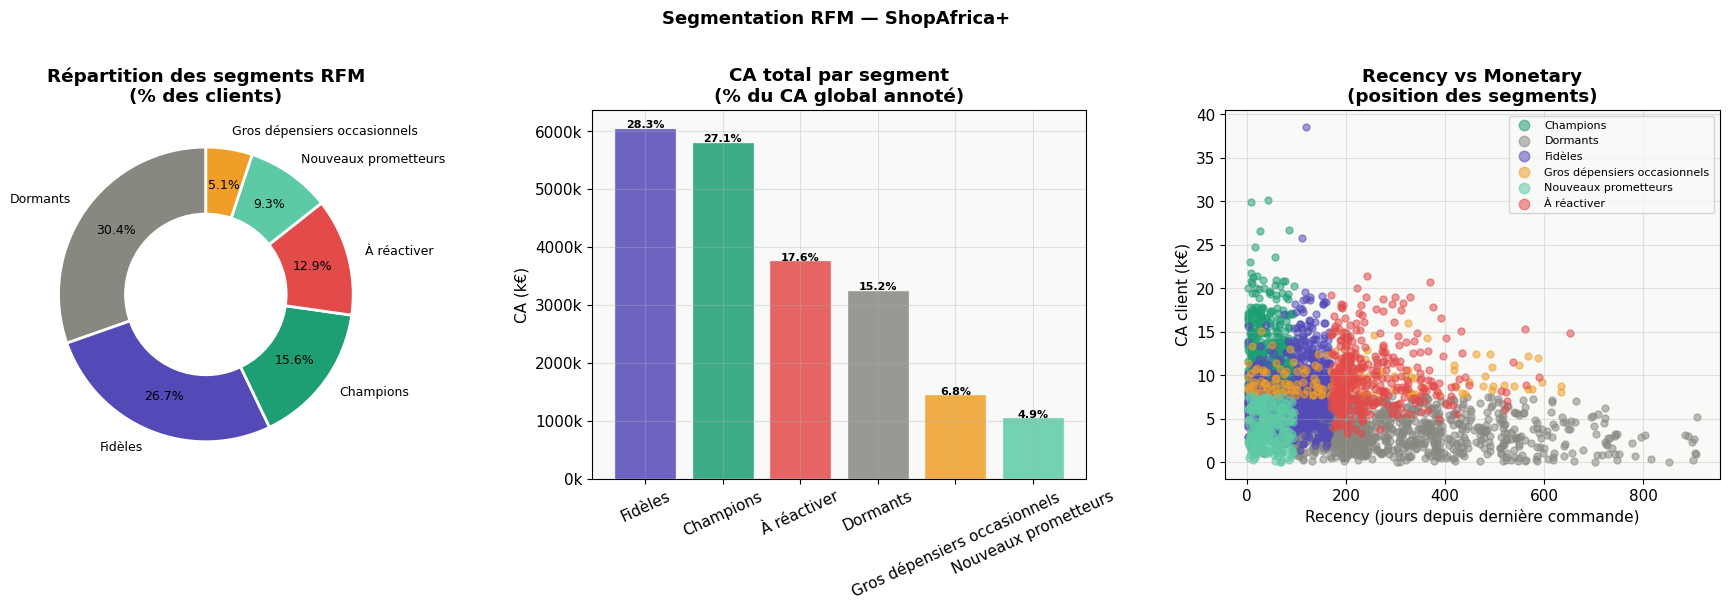

Sauvegardé : rfm_segmentation.png


In [84]:
colors_seg = {
    "Champions":                    COLORS["secondary"],
    "Fidèles":                      COLORS["primary"],
    "Gros dépensiers occasionnels": COLORS["warning"],
    "Nouveaux prometteurs":         "#5DCAA5",
    "À réactiver":                  COLORS["danger"],
    "Dormants":                     COLORS["neutral"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Donut : répartition des segments
dist_plot   = dist.set_index("segment")
plot_colors = [colors_seg.get(s, COLORS["neutral"]) for s in dist_plot.index]
axes[0].pie(
    dist_plot["nb_clients"],
    labels=dist_plot.index, colors=plot_colors,
    autopct="%1.1f%%", wedgeprops=dict(edgecolor="white", linewidth=2),
    startangle=90, pctdistance=0.75, labeldistance=1.12, textprops={"fontsize": 9}
)
axes[0].add_patch(plt.Circle((0, 0), 0.55, color="white"))
axes[0].set_title("Répartition des segments RFM\n(% des clients)", fontweight="bold")

# CA total par segment
ca_seg = (
    rfm.merge(df_liv.groupby("customer_id")["revenue"].sum().reset_index(), on="customer_id", how="left")
    .groupby("segment_rfm")["revenue"].sum()
    .sort_values(ascending=False)
)
ca_seg_pct = ca_seg / ca_seg.sum() * 100

seg_colors = [colors_seg.get(s, COLORS["neutral"]) for s in ca_seg.index]
bars = axes[1].bar(ca_seg.index, ca_seg.values / 1000, color=seg_colors, alpha=0.85, edgecolor="white")
for bar, v, pct in zip(bars, ca_seg.values / 1000, ca_seg_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{pct:.1f}%", ha="center", fontsize=8, fontweight="bold")
axes[1].set_title("CA total par segment\n(% du CA global annoté)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=25)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k"))
axes[1].set_ylabel("CA (k€)")

# Scatter Recency vs Monetary
for seg, grp in rfm.groupby("segment_rfm"):
    axes[2].scatter(
        grp["recency"], grp["monetary"] / 1000,
        alpha=0.55, s=25, label=seg, color=colors_seg.get(seg, COLORS["neutral"])
    )
axes[2].set_xlabel("Recency (jours depuis dernière commande)")
axes[2].set_ylabel("CA client (k€)")
axes[2].set_title("Recency vs Monetary\n(position des segments)", fontweight="bold")
axes[2].legend(fontsize=8, markerscale=1.5)

plt.suptitle("Segmentation RFM — ShopAfrica+", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("rfm_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : rfm_segmentation.png")

> **INTERPRÉTATION — Scatter Recency vs Monetary :**  
> Champions : en bas à gauche (récents ET fort CA).  
> À réactiver : en bas à droite (fort CA historique mais recency élevée — ce sont les clients à récupérer en priorité).  
> Dormants : dispersés avec peu de CA et pas récents.

---
## Étape 6 — Statistiques par segment

> **MÉTHODE — Les statistiques moyennes par segment permettent de vérifier que les segments sont bien différenciés.** Si les stats de deux segments sont très proches, ajuster les seuils dans `segment_rfm()`.

In [85]:
stats_seg = (
    rfm.groupby("segment_rfm")
    .agg(
        nb_clients    = ("customer_id", "count"),
        recency_moy   = ("recency",     "mean"),
        frequency_moy = ("frequency",   "mean"),
        monetary_moy  = ("monetary",    "mean"),
        r_moy         = ("R_score",     "mean"),
        f_moy         = ("F_score",     "mean"),
        m_moy         = ("M_score",     "mean")
    )
    .round(1)
    .sort_values("monetary_moy", ascending=False)
    .reset_index()
)
display(stats_seg)

# Contribution au CA par segment
ca_par_seg = (
    rfm
    .merge(df_liv.groupby("customer_id")["revenue"].sum().reset_index(), on="customer_id", how="left")
    .groupby("segment_rfm")["revenue"]
    .agg(["sum", "mean"]).round(0)
)
ca_par_seg.columns = ["CA total", "CA moyen/client"]
ca_par_seg["% du CA total"] = (ca_par_seg["CA total"] / ca_par_seg["CA total"].sum() * 100).round(1)
print("\nContribution au CA par segment :")
display(ca_par_seg.sort_values("CA total", ascending=False))

,segment_rfm,nb_clients,recency_moy,frequency_moy,monetary_moy,r_moy,f_moy,m_moy
0,Champions,467,40.30,8.10,12445.90,4.50,4.70,4.60
1,À réactiver,385,250.40,6.60,9794.70,1.70,4.00,4.00
2,Gros dépensiers occasionnels,152,199.20,3.90,9586.50,2.70,1.80,4.20
3,Fidèles,799,85.60,6.30,7579.30,3.80,3.80,3.20
4,Nouveaux prometteurs,277,42.70,3.40,3825.70,4.50,1.60,1.80
5,Dormants,907,310.40,3.40,3597.20,1.70,1.70,1.70



Contribution au CA par segment :


,CA total,CA moyen/client,% du CA total
segment_rfm,,,
Fidèles,6055823.00,7579.00,28.30
Champions,5812236.00,12446.00,27.10
À réactiver,3770968.00,9795.00,17.60
Dormants,3262645.00,3597.00,15.20
Gros dépensiers occasionnels,1457144.00,9586.00,6.80
Nouveaux prometteurs,1059724.00,3826.00,4.90


> **INTERPRÉTATION — Statistiques et contribution au CA par segment :**
>
> | Segment | Clients | CA total | CA moyen/client | % CA |
> |---|---|---|---|---|
> | Fidèles | 799 | 6 055 823€ | 7 579€ | **28.3%** |
> | Champions | 467 | 5 812 236€ | 12 446€ | **27.1%** |
> | À réactiver | 385 | 3 770 968€ | 9 795€ | **17.6%** |
> | Dormants | 907 | 3 262 645€ | 3 597€ | 15.2% |
> | Gros dépensiers occ. | 152 | 1 457 144€ | 9 586€ | 6.8% |
> | Nouveaux prometteurs | 277 | 1 059 724€ | 3 826€ | 4.9% |
>
> **Les 3 insights clés :**
>
> **1. Champions = 15.6% des clients mais 27.1% du CA** → ratio de concentration de 1.7x. Un Champion vaut 3.5 clients Dormants en termes de CA (12 446€ vs 3 597€)
>
> **2. Fidèles génèrent plus de CA que les Champions** (28.3% vs 27.1%) grâce à leur nombre (799 vs 467). Ils sont le vrai moteur de ShopAfrica+ — leur rétention est prioritaire
>
> **3. À réactiver = 17.6% du CA avec une recency de 250j** → c'est le levier le plus immédiat. 385 clients avec 9 795€ de monetary moyenne qui attendent d'être sollicités
>
> **MÉTIER :** *'Champions et Fidèles représentent 42% des clients et 55% du CA. Perdre 10% de ces clients coûterait ~1.1M€ de CA. Leur programme de fidélisation doit être la priorité absolue avant toute campagne d'acquisition.'*

---
## Étape 7 — Recommandations business par segment

| Segment | Qui sont-ils ? | Action prioritaire | KPI de succès |
|---|---|---|---|
| **Champions** | Récents, fréquents, gros dépensiers | Programme VIP, early access, referral | Rétention > 90% |
| **Fidèles** | Fréquents mais panier modéré | Upsell, cross-sell, offres premium | Hausse panier moyen |
| **Gros dépensiers occasionnels** | Fort panier, faible fréquence | Incentive fréquence, abonnement | +1 commande/an |
| **Nouveaux prometteurs** | 1er achat récent, potentiel | Welcome journey, 2ème achat dans 30j | Taux 2ème achat |
| **À réactiver** | Inactifs mais valeur historique | Email de réactivation + offre de retour | Taux de réactivation |
| **Dormants** | Faibles sur les 3 dimensions | CRM allégé, désabonnement | — |

---
## Étape 8 — Export du dataset RFM

In [86]:
# Export CSV vers SAVE_PATH (Drive ou local)
rfm.to_csv(f"{SAVE_PATH}clients_rfm_segments.csv", index=False)
print(f"Exporté : {SAVE_PATH}clients_rfm_segments.csv ({len(rfm):,} clients) ✅")
print(f"Colonnes : {rfm.columns.tolist()}")

rfm.head(10)

Exporté : ./outputs/clients_rfm_segments.csv (2,987 clients) ✅
Colonnes : ['customer_id', 'frequency', 'monetary', 'segment', 'pays', 'recency', 'R_score', 'F_score', 'M_score', 'rfm_score', 'rfm_total', 'segment_rfm']


,customer_id,frequency,monetary,segment,pays,recency,R_score,F_score,M_score,rfm_score,rfm_total,segment_rfm
0,CUS00001,1,99.00,Occasionnel,Senegal,195,2,1,1,211,4,Dormants
1,CUS00002,5,3559.00,Occasionnel,Cameroun,50,4,2,2,422,8,Nouveaux prometteurs
2,CUS00003,6,3519.00,Standard,Senegal,205,2,3,2,232,7,Dormants
3,CUS00004,6,5441.00,Standard,Senegal,14,5,3,2,532,10,Fidèles
4,CUS00005,6,13285.00,Occasionnel,Cote d'Ivoire,94,4,3,5,435,12,Fidèles
5,CUS00006,6,6003.00,Standard,Ghana,72,4,3,3,433,10,Fidèles
6,CUS00007,3,2523.00,Occasionnel,Cote d'Ivoire,193,2,1,1,211,4,Dormants
7,CUS00008,7,14049.00,Standard,Maroc,189,2,4,5,245,11,À réactiver
8,CUS00009,5,7531.00,Standard,Senegal,245,2,2,3,223,7,Dormants
9,CUS00010,1,36.00,Standard,Nigeria,852,1,1,1,111,3,Dormants


---
## Checklist de complétion

**Partie SQL — DuckDB (`%%sql`) :**
- [x] Bloc A — KPIs globaux (CA, marge, panier moyen en 2 étapes, clients actifs)
- [x] Bloc B — Analyse temporelle (strftime, LIMIT 3, anomalies avec LAG + CTE)
- [x] Bloc C — Catégories (RANK OVER pour double classement, top marques)
- [x] Bloc D — Clients (top 20, HAVING vs WHERE)
- [x] Bloc E — Canaux (SUM(SUM()) OVER pour part CA en %)
- [x] Bloc F — Risque (CASE WHEN conditionnel, CAST AS DOUBLE)
- [x] Bloc G — SQL avancé (ROW_NUMBER PARTITION BY, LAG, CTEs multiples, CROSS JOIN)

**Partie Python — RFM :**
- [x] Date de référence fixe (reproductibilité)
- [x] Métriques RFM calculées avec `nunique()` pour frequency
- [x] Scores via `pd.qcut` avec `rank(method='first')` pour les doublons
- [x] Labels inversés `[5,4,3,2,1]` pour Recency
- [x] Segmentation métier avec `apply(axis=1)`
- [x] 3 visualisations (donut, CA, scatter R vs M)
- [x] Statistiques par segment avec ratio valeur/volume
- [x] Recommandations actionnables par segment avec KPIs de succès
- [x] Export `clients_rfm_segments.csv`

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.